# Logistic Regression & Classification Metrics — Practical Notebook (Google Colab)

**Companion to:** `Logistic_Regression_Classification_Metrics_Session.html`

This notebook is built to run in **Google Colab**, reading files from **Google Drive**.
Every code cell has:

- A comment above each line explaining *what* it does and *why*
- Basic **error handling** so a missing file, wrong path, or bad column fails with a
  clear message instead of a cryptic traceback
- A genuinely thorough **EDA** section for both datasets — class balance, feature
  separability by class, correlation structure, and more
- A **threshold tuning** demonstration that directly connects to the business
  trade-off between Type I and Type II errors covered in the HTML session

**Structure**

- **Part 0 — Colab Setup**: mount Google Drive, define file paths
- **Part A — Binary Classification**: Breast Cancer dataset (malignant vs benign)
- **Part B — Multiclass Classification**: Iris dataset (3 species)
- **Part C — Workshop exercises**

Run the cells **top to bottom**.

## Part 0 — Colab Setup: Mount Google Drive

This notebook expects your files at:

```
/content/drive/MyDrive/notebooks/breast_cancer_data.csv
/content/drive/MyDrive/notebooks/iris.csv          (optional — falls back to sklearn's
                                                     built-in Iris dataset if not found)
```

Upload `breast_cancer_data.csv` into a folder named **notebooks** in your Google Drive
before running this cell. If you're running this notebook OUTSIDE Colab (e.g.
locally or on another platform), it will automatically skip the Drive mount and look
for the files in the current working directory instead.

In [1]:
# ── Detect whether we're running in Google Colab, and mount Drive if so ──────
import sys

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    try:
        from google.colab import drive
        drive.mount('/content/drive')
        DRIVE_BASE = "/content/drive/MyDrive/notebooks"
        print(f"✅ Google Drive mounted. Looking for files under: {DRIVE_BASE}")
    except Exception as e:
        print("❌ Could not mount Google Drive:", e)
        print("   Falling back to the current working directory instead.")
        DRIVE_BASE = "."
else:
    # Not running in Colab (e.g. local Jupyter) - just use the current folder
    DRIVE_BASE = "."
    print("Not running in Google Colab - using local file paths instead of Drive.")

BREAST_CANCER_PATH = f"{DRIVE_BASE}/breast_cancer_data.csv"
IRIS_CSV_PATH = f"{DRIVE_BASE}/iris.csv"

print(f"Breast cancer data path : {BREAST_CANCER_PATH}")
print(f"Iris CSV path (optional): {IRIS_CSV_PATH}")

Not running in Google Colab - using local file paths instead of Drive.
Breast cancer data path : ./breast_cancer_data.csv
Iris CSV path (optional): ./iris.csv


## Import Libraries

In [2]:
# ── Step-by-step setup with error handling ──────────────────────────────────
try:
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns

    from sklearn.model_selection import train_test_split
    from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import (
        accuracy_score, precision_score, recall_score, f1_score,
        confusion_matrix, classification_report,
        roc_curve, roc_auc_score, auc
    )
    from sklearn.datasets import load_iris

except ImportError as missing_library:
    print("A required library is missing:", missing_library)
    print("Fix it by running:  pip install numpy pandas matplotlib seaborn scikit-learn")
    raise

SEED = 42
np.random.seed(SEED)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.precision", 3)

print("✅ Setup complete. All libraries loaded successfully.")

✅ Setup complete. All libraries loaded successfully.


---
# PART A — Binary Classification: Breast Cancer Diagnosis

**Business context:** predicting whether a tumor is **malignant** (cancerous) or
**benign** (non-cancerous) from measurements taken from a digitized image of a
breast mass. This is a genuine binary classification problem where the cost of a
mistake is NOT symmetric — missing a real cancer (a false negative) is far more
dangerous than a false alarm (a false positive) that gets corrected by follow-up
testing. Keep this asymmetry in mind throughout Part A.

## A.1 Load the Data

In [3]:
# ── Load the breast cancer dataset, with error handling ──────────────────────
try:
    cancer_df = pd.read_csv(BREAST_CANCER_PATH)
    print(f"✅ Loaded breast_cancer_data.csv — {cancer_df.shape[0]} rows, {cancer_df.shape[1]} columns")
except FileNotFoundError:
    print(f"❌ File not found at: {BREAST_CANCER_PATH}")
    print("   If in Colab: make sure breast_cancer_data.csv is inside 'My Drive/notebooks/'.")
    print("   If running locally: make sure the file is in the current working directory.")
    raise

✅ Loaded breast_cancer_data.csv — 569 rows, 31 columns


## A.2 EDA — Step 1: First Look

In [4]:
print("Shape (rows, columns):", cancer_df.shape)
print()
display(cancer_df.head())
print()
cancer_df.info()

Shape (rows, columns): (569, 31)



,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.118,0.278,0.300,0.147,0.242,0.079,...,17.33,184.60,2019.0,0.162,0.666,0.712,0.265,0.460,0.119,0
1,20.57,17.77,132.90,1326.0,0.085,0.079,0.087,0.070,0.181,0.057,...,23.41,158.80,1956.0,0.124,0.187,0.242,0.186,0.275,0.089,0
2,19.69,21.25,130.00,1203.0,0.110,0.160,0.197,0.128,0.207,0.060,...,25.53,152.50,1709.0,0.144,0.424,0.450,0.243,0.361,0.088,0
3,11.42,20.38,77.58,386.1,0.142,0.284,0.241,0.105,0.260,0.097,...,26.50,98.87,567.7,0.210,0.866,0.687,0.258,0.664,0.173,0
4,20.29,14.34,135.10,1297.0,0.100,0.133,0.198,0.104,0.181,0.059,...,16.67,152.20,1575.0,0.137,0.205,0.400,0.163,0.236,0.077,0



<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-nul

## A.3 EDA — Step 2: Data Quality Checks

In [5]:
# ── Missing values ────────────────────────────────────────────────────────────
print("Missing values per column:")
print(cancer_df.isnull().sum().sum(), "total missing values across the whole dataset")

# ── Duplicate rows ────────────────────────────────────────────────────────────
n_duplicates = cancer_df.duplicated().sum()
print(f"\nDuplicate rows: {n_duplicates}")

if n_duplicates == 0 and cancer_df.isnull().sum().sum() == 0:
    print("\n✅ Dataset is clean - no missing values or duplicates to handle.")

Missing values per column:
0 total missing values across the whole dataset

Duplicate rows: 0

✅ Dataset is clean - no missing values or duplicates to handle.


## A.4 EDA — Step 3: Target Class Balance

**Why this matters for a business problem:** if one class heavily outnumbers the
other, a lazy model could achieve high accuracy just by always predicting the
majority class — which would be clinically useless. Always check class balance
before trusting an accuracy score.

Class distribution:
  Malignant (cancer): 212 (37.3%)
  Benign (no cancer): 357 (62.7%)


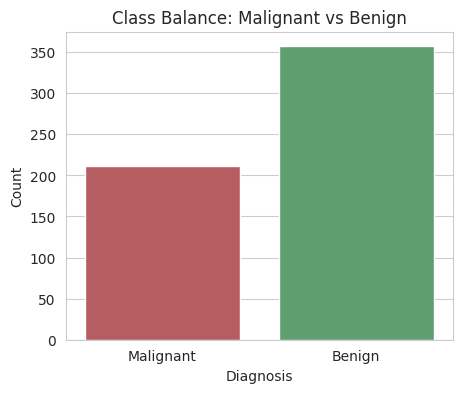


Moderate imbalance (about 63% benign / 37% malignant) - not extreme, but
worth keeping in mind. We'll use a STRATIFIED train/test split below to make
sure both classes are proportionally represented in both sets.


In [6]:
# target: 0 = malignant (cancer present), 1 = benign (no cancer) - this is the
# standard encoding used by sklearn's breast cancer dataset.
class_counts = cancer_df["target"].value_counts().sort_index()
class_labels = {0: "Malignant (cancer)", 1: "Benign (no cancer)"}

print("Class distribution:")
for cls, count in class_counts.items():
    pct = count / len(cancer_df) * 100
    print(f"  {class_labels[cls]}: {count} ({pct:.1f}%)")

plt.figure(figsize=(5, 4))
sns.countplot(x=cancer_df["target"], hue=cancer_df["target"], palette=["#C44E52", "#55A868"], legend=False)
plt.xticks([0, 1], ["Malignant", "Benign"])
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.title("Class Balance: Malignant vs Benign")
plt.show()

print("\nModerate imbalance (about 63% benign / 37% malignant) - not extreme, but")
print("worth keeping in mind. We'll use a STRATIFIED train/test split below to make")
print("sure both classes are proportionally represented in both sets.")

## A.5 EDA — Step 4: Descriptive Statistics

In [7]:
display(cancer_df.describe())

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,...,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000
mean,14.127,19.290,91.969,654.889,0.096,0.104,0.089,0.049,0.181,0.063,...,25.677,107.261,880.583,0.132,0.254,0.272,0.115,0.290,0.084,0.627
std,3.524,4.301,24.299,351.914,0.014,0.053,0.080,0.039,0.027,0.007,...,6.146,33.603,569.357,0.023,0.157,0.209,0.066,0.062,0.018,0.484
min,6.981,9.710,43.790,143.500,0.053,0.019,0.000,0.000,0.106,0.050,...,12.020,50.410,185.200,0.071,0.027,0.000,0.000,0.157,0.055,0.000
25%,11.700,16.170,75.170,420.300,0.086,0.065,0.030,0.020,0.162,0.058,...,21.080,84.110,515.300,0.117,0.147,0.115,0.065,0.250,0.071,0.000
50%,13.370,18.840,86.240,551.100,0.096,0.093,0.062,0.034,0.179,0.062,...,25.410,97.660,686.500,0.131,0.212,0.227,0.100,0.282,0.080,1.000
75%,15.780,21.800,104.100,782.700,0.105,0.130,0.131,0.074,0.196,0.066,...,29.720,125.400,1084.000,0.146,0.339,0.383,0.161,0.318,0.092,1.000
max,28.110,39.280,188.500,2501.000,0.163,0.345,0.427,0.201,0.304,0.097,...,49.540,251.200,4254.000,0.223,1.058,1.252,0.291,0.664,0.207,1.000


## A.6 EDA — Step 5: Do the Features Actually Separate the Classes?

Before modeling, it's worth checking visually whether malignant and benign tumors
actually look different on key features — if they didn't, no model could
distinguish them well either.

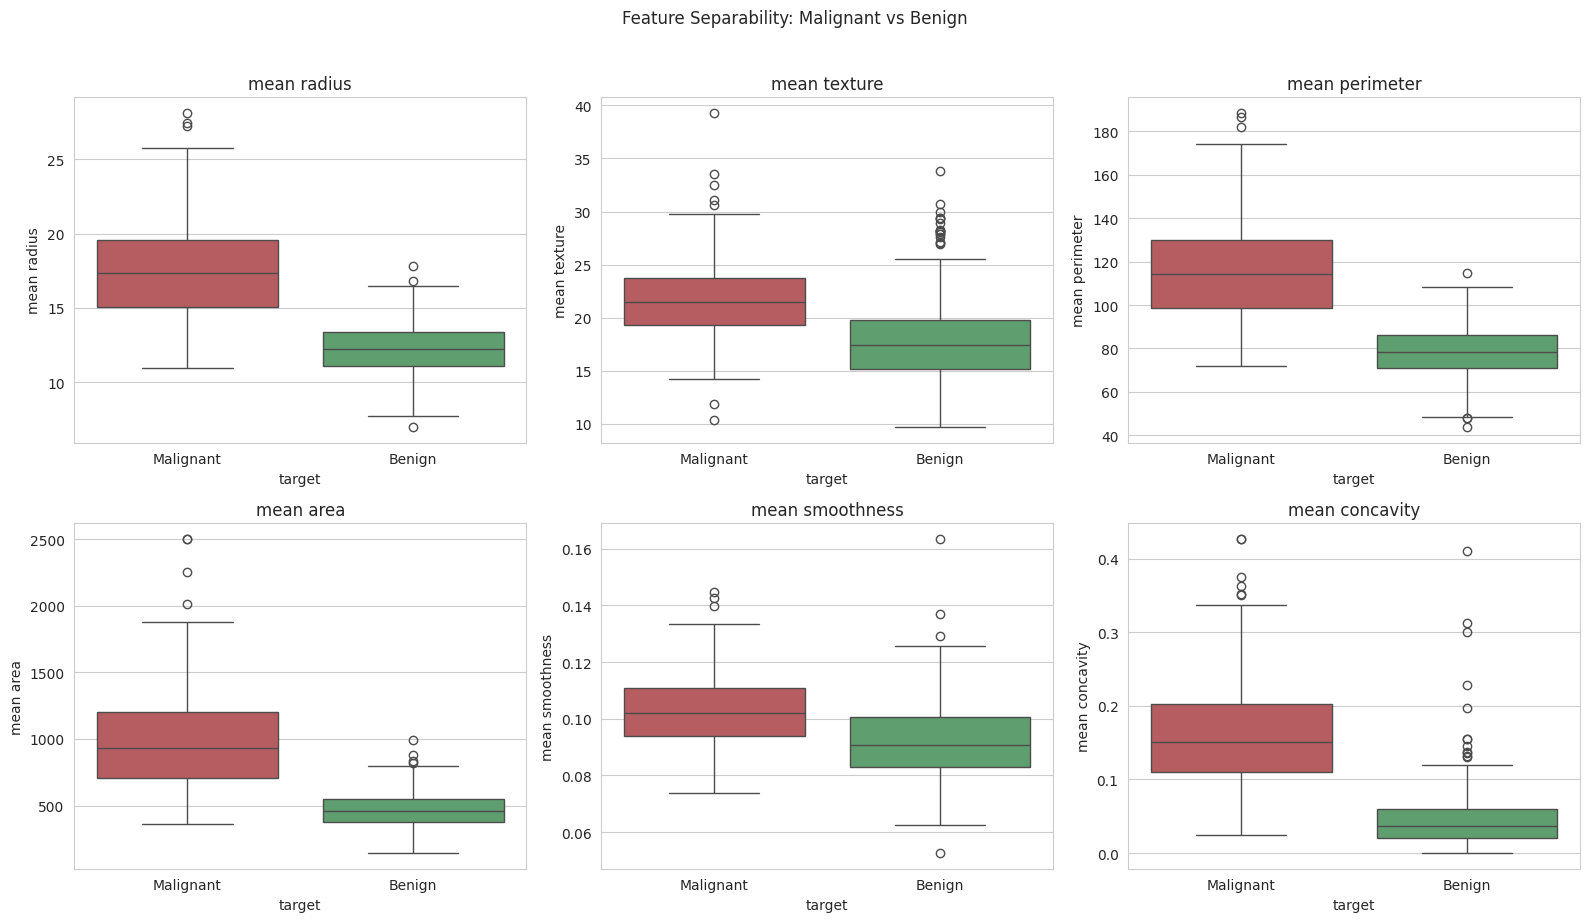

In [8]:
key_features = ["mean radius", "mean texture", "mean perimeter", "mean area",
                 "mean smoothness", "mean concavity"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, feature in enumerate(key_features):
    sns.boxplot(data=cancer_df, x="target", y=feature, hue="target",
                palette=["#C44E52", "#55A868"], legend=False, ax=axes[i])
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(["Malignant", "Benign"])
    axes[i].set_title(feature)

plt.suptitle("Feature Separability: Malignant vs Benign", y=1.02)
plt.tight_layout()
plt.show()

**EDA takeaway:** malignant tumors clearly tend toward larger radius, perimeter,
area, and concavity than benign ones — a strong early signal that these features
will be genuinely useful to the model, not just noise.

## A.7 EDA — Step 6: Correlation Heatmap

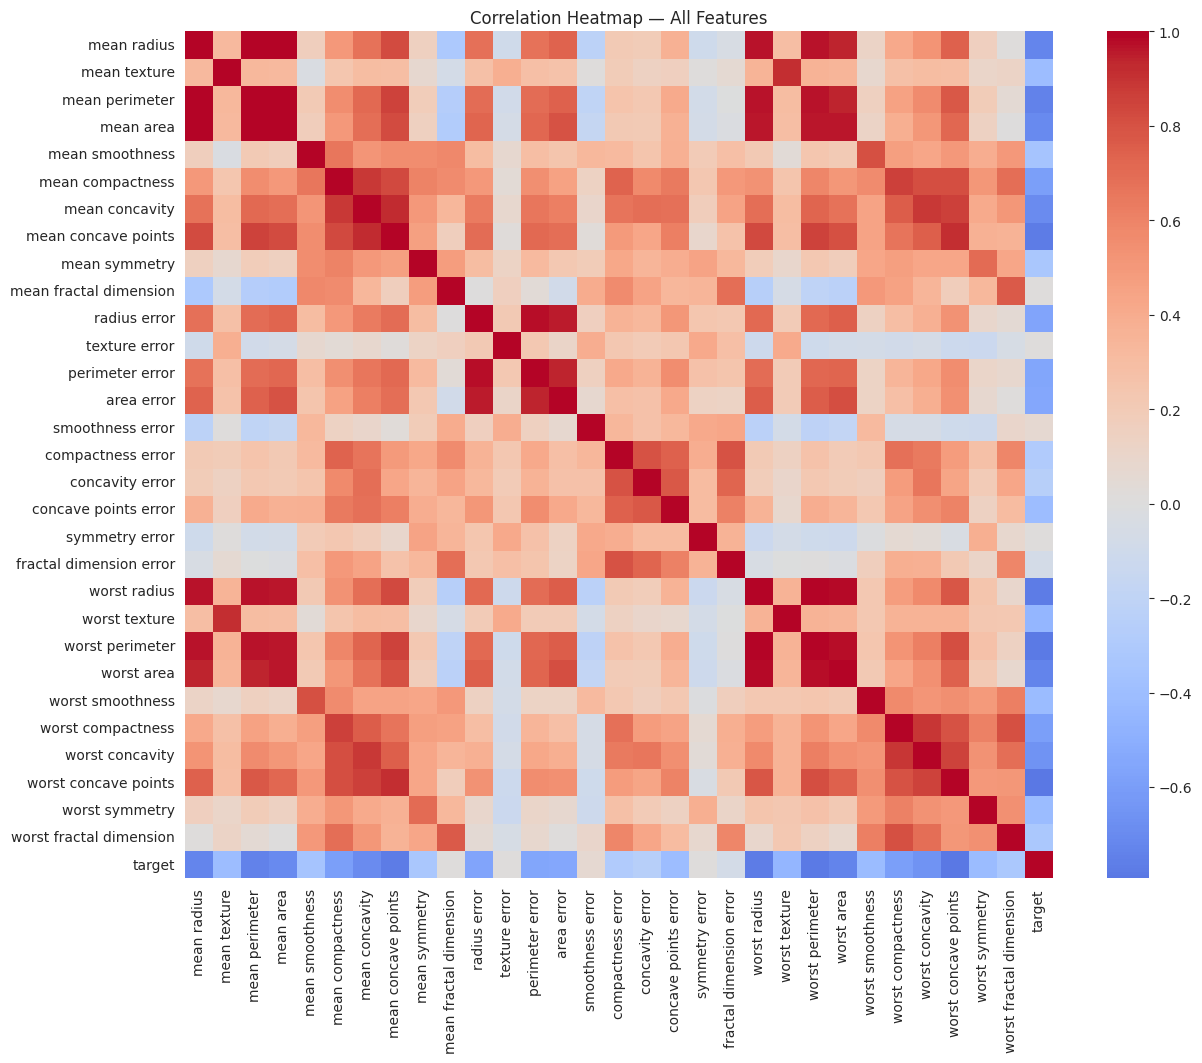

Top 10 features most correlated with the target (malignant=0, benign=1):
worst concave points   -0.794
worst perimeter        -0.783
mean concave points    -0.777
worst radius           -0.776
mean perimeter         -0.743
worst area             -0.734
mean radius            -0.730
mean area              -0.709
mean concavity         -0.696
worst concavity        -0.660
Name: target, dtype: float64


In [9]:
plt.figure(figsize=(14, 11))
correlation_matrix = cancer_df.corr()
sns.heatmap(correlation_matrix, annot=False, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap — All Features")
plt.show()

print("Top 10 features most correlated with the target (malignant=0, benign=1):")
print(correlation_matrix["target"].sort_values().head(10))

**EDA takeaway:** several "worst" and "mean" measurements (radius, perimeter,
area, concavity, concave points) are strongly negatively correlated with the target
— remember target=1 is benign, so a strong NEGATIVE correlation means these features
are strongly associated with malignancy, consistent with what the boxplots just showed.

## A.8 Data Preprocessing — Define Features/Target and Split

In [10]:
# ── Separate features from target ─────────────────────────────────────────────
try:
    X_cancer = cancer_df.drop("target", axis=1)
    y_cancer = cancer_df["target"]
except KeyError as e:
    print(f"Column not found: {e}. Check the dataset has a 'target' column.")
    raise

# ── Stratified split: preserves the ~63/37 class ratio in both train and test ────
X_train, X_test, y_train, y_test = train_test_split(
    X_cancer, y_cancer, test_size=0.2, random_state=SEED, stratify=y_cancer
)

print(f"Training rows: {len(X_train)}  |  Testing rows: {len(X_test)}")
print(f"Training set malignant %: {(y_train == 0).mean()*100:.1f}%")
print(f"Testing set malignant % : {(y_test == 0).mean()*100:.1f}%  (should closely match training)")

Training rows: 455  |  Testing rows: 114
Training set malignant %: 37.4%
Testing set malignant % : 36.8%  (should closely match training)


## A.9 Feature Scaling

**Why scaling matters here (unlike plain linear regression in Day 1/Day 2):**
scikit-learn's `LogisticRegression` applies L2 regularization by default, and
regularization penalizes large coefficients — which unfairly punishes features
measured on larger numeric scales (like "mean area", in the hundreds) compared to
features on smaller scales (like "mean smoothness", a small decimal). Scaling puts
every feature on equal footing before that penalty is applied.

In [11]:
# ── Fit the scaler on TRAINING data only, then apply to both sets ────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling complete.")
print(f"Mean of scaled training features (should be ≈0): {X_train_scaled.mean():.4f}")
print(f"Std of scaled training features (should be ≈1) : {X_train_scaled.std():.4f}")

Scaling complete.
Mean of scaled training features (should be ≈0): 0.0000
Std of scaled training features (should be ≈1) : 1.0000


## A.10 Train the Logistic Regression Model

In [12]:
cancer_model = LogisticRegression(random_state=SEED, max_iter=5000)
cancer_model.fit(X_train_scaled, y_train)
print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


## A.11 Predictions and the Confusion Matrix

**Important framing decision:** clinically, "positive" should mean "has cancer"
(malignant = 0 in this dataset's encoding), NOT whichever label sklearn happens to
call "1" by default. We explicitly tell every metric function which label is the
positive class so our precision/recall numbers mean what a doctor would expect
them to mean.

Confusion Matrix (positive class = Malignant):
                  Predicted Malignant   Predicted Benign
Actual Malignant        TP = 41                FN = 1
Actual Benign           FP = 1                 TN = 71


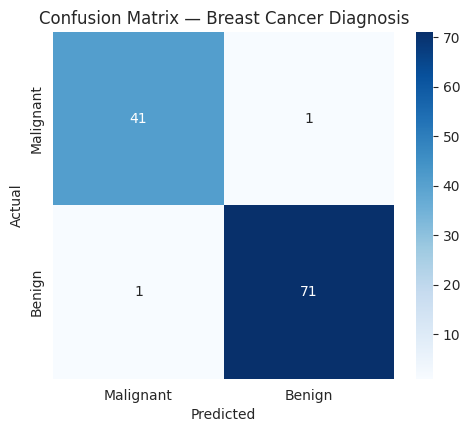

In [13]:
y_pred = cancer_model.predict(X_test_scaled)

# Explicitly treat malignant (0) as the positive class for clinical interpretation
POSITIVE_LABEL = 0   # malignant = the condition we are trying to detect

cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
# With labels=[0,1]: cm[0,0]=TP, cm[0,1]=FN, cm[1,0]=FP, cm[1,1]=TN  (positive=malignant=0)
TP, FN, FP, TN = cm[0, 0], cm[0, 1], cm[1, 0], cm[1, 1]

print("Confusion Matrix (positive class = Malignant):")
print(f"                  Predicted Malignant   Predicted Benign")
print(f"Actual Malignant        TP = {TP}                FN = {FN}")
print(f"Actual Benign           FP = {FP}                 TN = {TN}")

plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Malignant", "Benign"], yticklabels=["Malignant", "Benign"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Breast Cancer Diagnosis")
plt.show()

## A.12 Classification Metrics — Computed Explicitly

In [14]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label=POSITIVE_LABEL)
recall = recall_score(y_test, y_pred, pos_label=POSITIVE_LABEL)      # a.k.a. Sensitivity
specificity = TN / (TN + FP)                                          # True Negative Rate
f1 = f1_score(y_test, y_pred, pos_label=POSITIVE_LABEL)

print(f"Accuracy    : {accuracy:.4f}")
print(f"Precision   : {precision:.4f}  (of predicted-malignant cases, how many really were)")
print(f"Recall      : {recall:.4f}  (of actually-malignant cases, how many we caught)")
print(f"Specificity : {specificity:.4f}  (of actually-benign cases, how many we correctly cleared)")
print(f"F1-Score    : {f1:.4f}")

print("\nFull classification report (sklearn's default view, benign=1 as 'positive'):")
print(classification_report(y_test, y_pred, target_names=["Malignant", "Benign"]))

print(f"\nType I error rate  (alpha, false alarm rate)   = FP/(FP+TN) = {FP/(FP+TN):.4f}")
print(f"Type II error rate (beta, missed-cancer rate)   = FN/(FN+TP) = {FN/(FN+TP):.4f}")
print(f"Statistical Power  (1 - beta) = Recall/Sensitivity = {1 - FN/(FN+TP):.4f}")

Accuracy    : 0.9825
Precision   : 0.9762  (of predicted-malignant cases, how many really were)
Recall      : 0.9762  (of actually-malignant cases, how many we caught)
Specificity : 0.9861  (of actually-benign cases, how many we correctly cleared)
F1-Score    : 0.9762

Full classification report (sklearn's default view, benign=1 as 'positive'):


              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        42
      Benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


Type I error rate  (alpha, false alarm rate)   = FP/(FP+TN) = 0.0139
Type II error rate (beta, missed-cancer rate)   = FN/(FN+TP) = 0.0238
Statistical Power  (1 - beta) = Recall/Sensitivity = 0.9762


**Business interpretation:** with only a small number missed cancer case(s) out of the total
actual malignant cases in the test set, this model's recall/sensitivity is very high
— exactly the priority in a cancer-screening context, where a missed diagnosis
(Type II error) is far more dangerous than a false alarm (Type I error) that simply
triggers a follow-up test.

## A.13 ROC Curve and AUC

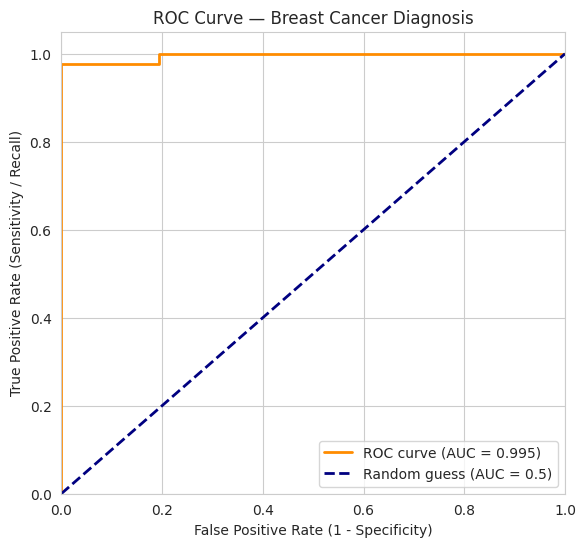

AUC = 0.9954 — very close to 1.0, meaning the model separates the two
classes almost perfectly across every possible decision threshold.
(Sanity check passed: matches default-orientation AUC of 0.9954)


In [15]:
y_pred_proba = cancer_model.predict_proba(X_test_scaled)[:, POSITIVE_LABEL]

# IMPORTANT: this installed version of scikit-learn's roc_auc_score does not accept
# a pos_label argument for the binary case - it always scores against whichever
# label is treated as "1". To correctly score with malignant as the positive class,
# we recode the true labels so malignant=1, matching our probability column.
y_test_recoded_for_auc = (y_test == POSITIVE_LABEL).astype(int)  # 1 = malignant, 0 = benign

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba, pos_label=POSITIVE_LABEL)
roc_auc = roc_auc_score(y_test_recoded_for_auc, y_pred_proba)

plt.figure(figsize=(6.5, 6))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--", label="Random guess (AUC = 0.5)")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Sensitivity / Recall)")
plt.title("ROC Curve — Breast Cancer Diagnosis")
plt.legend(loc="lower right")
plt.show()

print(f"AUC = {roc_auc:.4f} — very close to 1.0, meaning the model separates the two")
print("classes almost perfectly across every possible decision threshold.")

# Sanity check: for binary classification, AUC is invariant to which class is
# labeled "positive" - it should match the AUC computed the "default" sklearn way.
default_way_auc = roc_auc_score(y_test, cancer_model.predict_proba(X_test_scaled)[:, 1])
assert abs(roc_auc - default_way_auc) < 1e-9, "AUC mismatch - check positive class encoding!"
print(f"(Sanity check passed: matches default-orientation AUC of {default_way_auc:.4f})")

## A.14 Threshold Tuning — Connecting Directly to the Type I/II Trade-off

The default classification threshold is 0.5, but nothing forces us to use it.
**Lowering the threshold for "predict malignant"** makes the model flag more cases
as malignant — catching more true cancers (higher recall) at the cost of more false
alarms (lower precision). This is exactly the business lever discussed in the HTML
session: in cancer screening, we often deliberately accept a lower threshold.

In [16]:
def evaluate_at_threshold(y_true, y_proba, threshold, positive_label=0):
    """Re-classify using a custom threshold and return TP, FN, FP, TN, precision, recall."""
    if not 0 < threshold < 1:
        raise ValueError("threshold must be strictly between 0 and 1")

    # y_proba here is P(malignant); predict malignant if that probability >= threshold
    y_pred_custom = np.where(y_proba >= threshold, 0, 1)  # 0=malignant if prob high enough

    cm_t = confusion_matrix(y_true, y_pred_custom, labels=[0, 1])
    tp, fn, fp, tn = cm_t[0, 0], cm_t[0, 1], cm_t[1, 0], cm_t[1, 1]

    precision_t = tp / (tp + fp) if (tp + fp) > 0 else np.nan
    recall_t = tp / (tp + fn) if (tp + fn) > 0 else np.nan

    return {"threshold": threshold, "TP": tp, "FN": fn, "FP": fp, "TN": tn,
            "precision": precision_t, "recall": recall_t}


# We need P(malignant), so flip the standard predict_proba output accordingly
proba_malignant = cancer_model.predict_proba(X_test_scaled)[:, 0]

threshold_results = [evaluate_at_threshold(y_test, proba_malignant, t)
                     for t in [0.3, 0.4, 0.5, 0.6, 0.7]]

threshold_df = pd.DataFrame(threshold_results)
display(threshold_df)

print("\nNotice: as the threshold drops, FN (missed cancers) tends to fall while FP")
print("(false alarms) tends to rise - precision and recall move in opposite directions.")
print("A hospital might deliberately choose a LOWER threshold than 0.5 to prioritize recall.")

,threshold,TP,FN,FP,TN,precision,recall
0,0.3,41,1,5,67,0.891,0.976
1,0.4,41,1,4,68,0.911,0.976
2,0.5,41,1,1,71,0.976,0.976
3,0.6,41,1,1,71,0.976,0.976
4,0.7,40,2,0,72,1.000,0.952



Notice: as the threshold drops, FN (missed cancers) tends to fall while FP
(false alarms) tends to rise - precision and recall move in opposite directions.
A hospital might deliberately choose a LOWER threshold than 0.5 to prioritize recall.


## A.15 Interpret the Coefficients

In [17]:
coef_df = pd.DataFrame({
    "Feature": X_cancer.columns,
    "Coefficient": cancer_model.coef_[0]
}).sort_values("Coefficient", key=abs, ascending=False)

print("Top 10 most influential features (by absolute coefficient size):")
display(coef_df.head(10))

print("\nRemember: since target=1 is 'benign', a POSITIVE coefficient pushes the")
print("prediction TOWARD benign, and a NEGATIVE coefficient pushes it TOWARD malignant.")

Top 10 most influential features (by absolute coefficient size):


,Feature,Coefficient
21,worst texture,-1.255
10,radius error,-1.083
27,worst concave points,-0.954
23,worst area,-0.948
20,worst radius,-0.948
28,worst symmetry,-0.939
13,area error,-0.929
26,worst concavity,-0.823
22,worst perimeter,-0.763
24,worst smoothness,-0.747



Remember: since target=1 is 'benign', a POSITIVE coefficient pushes the
prediction TOWARD benign, and a NEGATIVE coefficient pushes it TOWARD malignant.


---
# PART B — Multiclass Classification: Iris Species

**Business context:** classifying an iris flower into one of three species
(setosa, versicolor, virginica) from four physical measurements. This demonstrates
how logistic regression extends beyond two classes using the **softmax function**.

## B.1 Load the Data

We first look for `iris.csv` on Google Drive (matching the original course
material). If it isn't found, we fall back to scikit-learn's built-in Iris dataset
— the same classic data, just loaded a different way, so the notebook still runs
even if that specific file wasn't uploaded.

In [18]:
# ── Try loading iris.csv from Drive first, fall back to sklearn's built-in version ─
try:
    iris_df = pd.read_csv(IRIS_CSV_PATH)
    # Try to find a species/target-like column, since CSV exports vary in naming
    target_col_candidates = [c for c in iris_df.columns if c.lower() in ("species", "target", "class")]
    if not target_col_candidates:
        raise ValueError("Could not find a species/target column in iris.csv")
    target_col = target_col_candidates[0]
    print(f"✅ Loaded iris.csv from Drive — using '{target_col}' as the target column.")

except (FileNotFoundError, ValueError) as e:
    print(f"iris.csv not found or unusable at {IRIS_CSV_PATH} ({e})")
    print("Falling back to scikit-learn's built-in Iris dataset instead.")

    iris_bunch = load_iris(as_frame=True)
    iris_df = iris_bunch.frame.copy()
    # Map the numeric target (0,1,2) to readable species names, matching the classic dataset
    species_names = dict(enumerate(iris_bunch.target_names))
    iris_df["species"] = iris_df["target"].map(species_names)
    iris_df = iris_df.drop(columns=["target"])
    target_col = "species"

print(f"\nFinal shape: {iris_df.shape}, target column: '{target_col}'")
display(iris_df.head())

iris.csv not found or unusable at ./iris.csv ([Errno 2] No such file or directory: './iris.csv')
Falling back to scikit-learn's built-in Iris dataset instead.

Final shape: (150, 5), target column: 'species'


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## B.2 EDA — Class Counts and Summary Statistics

In [19]:
print("Class counts:")
print(iris_df[target_col].value_counts())
print()
display(iris_df.describe())

Class counts:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64



,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000,150.000,150.000,150.000
mean,5.843,3.057,3.758,1.199
std,0.828,0.436,1.765,0.762
min,4.300,2.000,1.000,0.100
25%,5.100,2.800,1.600,0.300
50%,5.800,3.000,4.350,1.300
75%,6.400,3.300,5.100,1.800
max,7.900,4.400,6.900,2.500


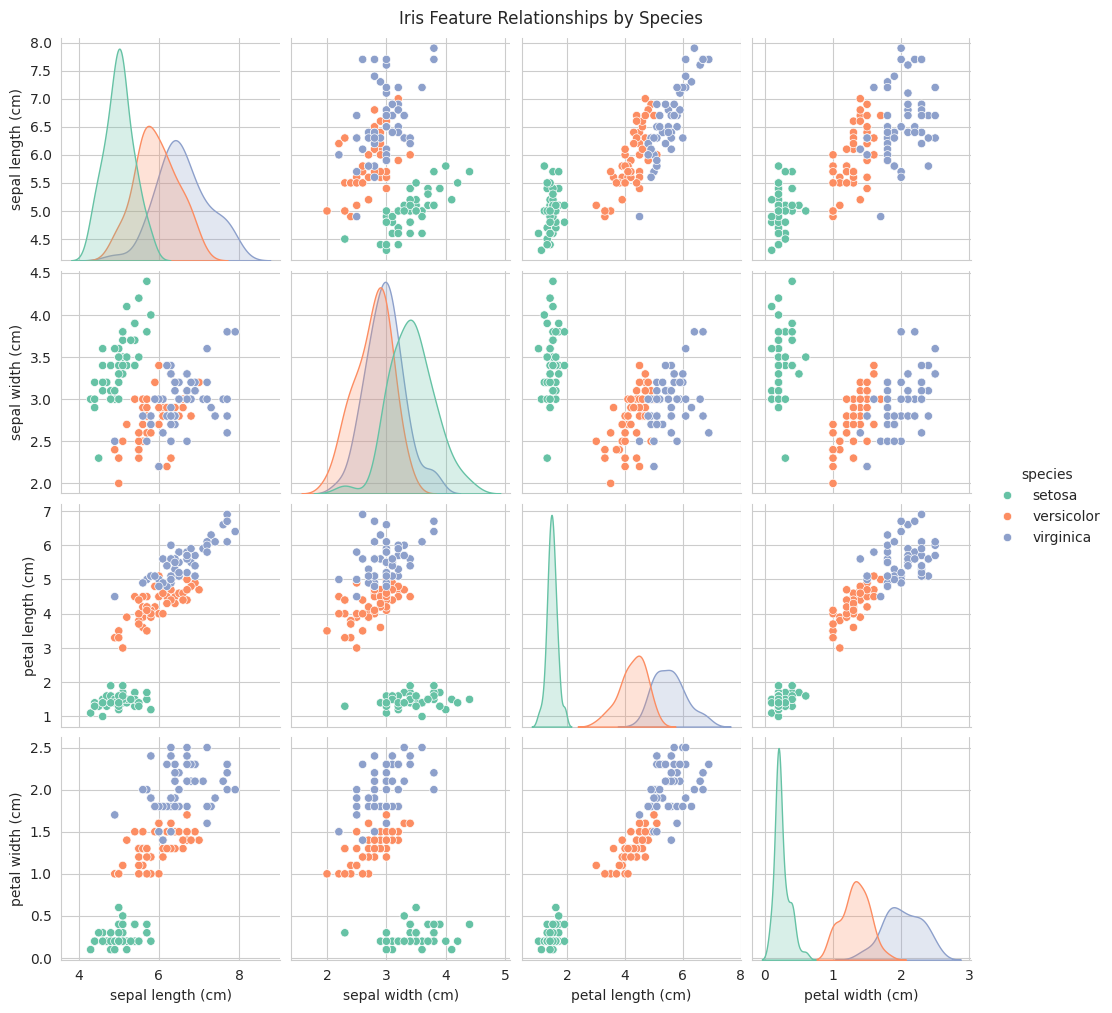

In [20]:
# ── Pairplot: visualize how well the 4 features separate the 3 species ──────
sns.pairplot(iris_df, hue=target_col, palette="Set2")
plt.suptitle("Iris Feature Relationships by Species", y=1.01)
plt.show()

**EDA takeaway:** setosa is clearly, linearly separable from the other two
species on almost every feature pair — versicolor and virginica overlap more,
which is exactly where we should expect the model to make most of its mistakes.

## B.3 Data Preprocessing

In [21]:
# ── Separate features and target ─────────────────────────────────────────────
X_iris = iris_df.drop(columns=[target_col])
y_iris_raw = iris_df[target_col]

# ── Encode the target properly with LabelEncoder (more robust than pd.factorize,
#    since it remembers the mapping via .classes_ for later use in plots) ────────
label_encoder = LabelEncoder()
y_iris = label_encoder.fit_transform(y_iris_raw)

print("Species label mapping:")
for i, cls in enumerate(label_encoder.classes_):
    print(f"  {i} -> {cls}")

# ── Stratified train/test split (keeps the 50/50/50 balance in both sets) ───────
X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(
    X_iris, y_iris, test_size=0.2, random_state=SEED, stratify=y_iris
)
print(f"\nTraining rows: {len(X_train_i)}  |  Testing rows: {len(X_test_i)}")

Species label mapping:
  0 -> setosa
  1 -> versicolor
  2 -> virginica

Training rows: 120  |  Testing rows: 30


In [22]:
# ── Scale features (same reasoning as Part A) ────────────────────────────────
scaler_iris = StandardScaler()
X_train_i_scaled = scaler_iris.fit_transform(X_train_i)
X_test_i_scaled = scaler_iris.transform(X_test_i)
print("Scaling complete.")

Scaling complete.


## B.4 Train the Multiclass Logistic Regression Model

With more than 2 classes, scikit-learn automatically uses a **softmax**-based
multinomial approach (rather than training separate one-vs-rest models), which is
what the "Multiclass Logistic Regression" section of the HTML session describes.

In [23]:
iris_model = LogisticRegression(max_iter=1000, random_state=SEED)
iris_model.fit(X_train_i_scaled, y_train_i)
print("Multiclass Logistic Regression model trained successfully.")
print(f"Number of classes: {len(iris_model.classes_)}")

Multiclass Logistic Regression model trained successfully.
Number of classes: 3


## B.5 Evaluate — Classification Report and Confusion Matrix

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



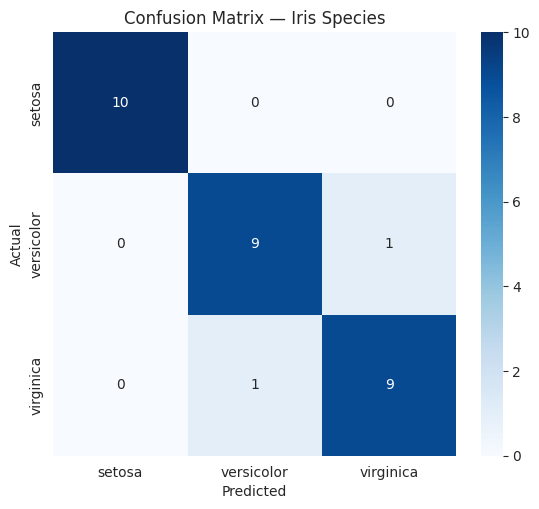

In [24]:
y_pred_i = iris_model.predict(X_test_i_scaled)

print("Classification Report:")
print(classification_report(y_test_i, y_pred_i, target_names=label_encoder.classes_))

cm_iris = confusion_matrix(y_test_i, y_pred_i)
plt.figure(figsize=(6.5, 5.5))
sns.heatmap(cm_iris, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Iris Species")
plt.show()

**Reading a multiclass confusion matrix:** the diagonal cells are correct
predictions; any off-diagonal cell shows exactly which two classes are being
confused for each other — typically versicolor and virginica here, matching what
the pairplot already hinted at.

## B.6 ROC Curves — One-vs-Rest for Each Class

ROC curves are naturally defined for binary problems, so for 3 classes we compute
one ROC curve per class, treating "this class" vs "all other classes" as a binary
problem each time (this is the corrected, working version of the same idea from
the original course notebook).

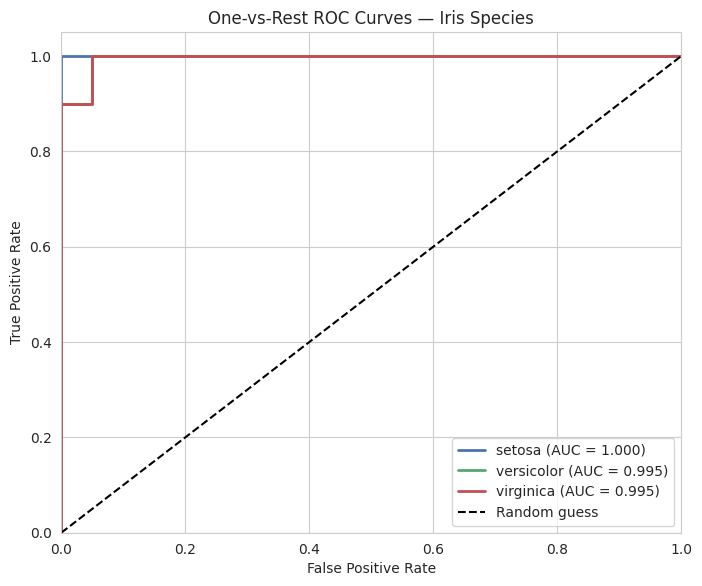

In [25]:
n_classes = len(label_encoder.classes_)

# Binarize the ALREADY-ENCODED test labels (0,1,2) - fixes a subtle bug in the original
# notebook, which tried to binarize the raw string labels against numeric class values.
y_test_i_bin = label_binarize(y_test_i, classes=list(range(n_classes)))
y_proba_i = iris_model.predict_proba(X_test_i_scaled)

fpr_dict, tpr_dict, auc_dict = {}, {}, {}
for i in range(n_classes):
    fpr_dict[i], tpr_dict[i], _ = roc_curve(y_test_i_bin[:, i], y_proba_i[:, i])
    auc_dict[i] = auc(fpr_dict[i], tpr_dict[i])

plt.figure(figsize=(8, 6.5))
colors = ["#4C72B0", "#55A868", "#C44E52"]
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr_dict[i], tpr_dict[i], color=color, lw=2,
              label=f"{label_encoder.classes_[i]} (AUC = {auc_dict[i]:.3f})")

plt.plot([0, 1], [0, 1], "k--", lw=1.5, label="Random guess")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("One-vs-Rest ROC Curves — Iris Species")
plt.legend(loc="lower right")
plt.show()

## B.7 Interpret the Model

In [26]:
coef_iris_df = pd.DataFrame(
    iris_model.coef_, columns=X_iris.columns, index=label_encoder.classes_
)
print("Coefficients per class (each row is that class's own set of coefficients):")
display(coef_iris_df)

Coefficients per class (each row is that class's own set of coefficients):


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
setosa,-1.089,1.024,-1.799,-1.686
versicolor,0.536,-0.360,-0.204,-0.808
virginica,0.553,-0.664,2.003,2.494


---
# PART C — Workshop: Practice Exercises

### Task 1 — Threshold Tuning Discussion
Using `evaluate_at_threshold()` from Part A, find the threshold that gives 100%
recall (catches every malignant case) on this test set. What does precision drop
to at that threshold? Is that trade-off worth it in your opinion, and why?

In [27]:
# ── Your solution here ────────────────────────────────────────────────────────
for t in np.arange(0.05, 0.95, 0.05):
    result = evaluate_at_threshold(y_test, proba_malignant, round(t, 2))
    if result["FN"] == 0:
        print(f"Threshold {result['threshold']:.2f}: FN=0 (100% recall), "
              f"precision={result['precision']:.3f}, FP={result['FP']}")
        break
else:
    print("No threshold in the tested range achieved 100% recall.")

Threshold 0.05: FN=0 (100% recall), precision=0.700, FP=18


### Task 2 — Specificity by Hand
Using the confusion matrix values from Part A (TP, FN, FP, TN), manually compute
specificity and confirm it matches the value calculated in Section A.12.

In [28]:
specificity_manual = TN / (TN + FP)
print(f"Specificity (manual): {specificity_manual:.4f}")
print(f"Specificity (from A.12): {specificity:.4f}")
assert np.isclose(specificity_manual, specificity), "Mismatch!"
print("✅ Matches.")

Specificity (manual): 0.9861
Specificity (from A.12): 0.9861
✅ Matches.


### Task 3 — Feature Importance Comparison
Compare the top 5 coefficients (by absolute value) between the breast cancer model
and think about whether they make clinical sense given what you know about tumors.

In [29]:
print("Top 5 breast cancer model coefficients:")
display(coef_df.head(5))

Top 5 breast cancer model coefficients:


,Feature,Coefficient
21,worst texture,-1.255
10,radius error,-1.083
27,worst concave points,-0.954
23,worst area,-0.948
20,worst radius,-0.948


### Task 4 — Class Imbalance Simulation (Bonus)
Artificially create a heavily imbalanced version of the breast cancer dataset by
keeping only 20 malignant cases (out of the original ~212) while keeping all benign
cases. Retrain the model and observe what happens to recall for malignant cases.
This demonstrates why class imbalance is a serious concern in real medical datasets.

In [30]:
# ── Build an artificially imbalanced dataset ──────────────────────────────────
malignant_subset = cancer_df[cancer_df["target"] == 0].sample(n=20, random_state=SEED)
benign_subset = cancer_df[cancer_df["target"] == 1]
imbalanced_df = pd.concat([malignant_subset, benign_subset]).sample(frac=1, random_state=SEED)

print("New class balance:")
print(imbalanced_df["target"].value_counts())

X_imb = imbalanced_df.drop("target", axis=1)
y_imb = imbalanced_df["target"]

X_train_imb, X_test_imb, y_train_imb, y_test_imb = train_test_split(
    X_imb, y_imb, test_size=0.2, random_state=SEED, stratify=y_imb
)

scaler_imb = StandardScaler()
X_train_imb_scaled = scaler_imb.fit_transform(X_train_imb)
X_test_imb_scaled = scaler_imb.transform(X_test_imb)

model_imb = LogisticRegression(random_state=SEED, max_iter=5000)
model_imb.fit(X_train_imb_scaled, y_train_imb)
y_pred_imb = model_imb.predict(X_test_imb_scaled)

recall_imb = recall_score(y_test_imb, y_pred_imb, pos_label=0)
print(f"\nRecall for malignant class on the IMBALANCED dataset: {recall_imb:.3f}")
print(f"(compare to {recall:.3f} on the original, more balanced dataset)")
print("\nA drop here shows how class imbalance alone can hurt the model's ability")
print("to catch the minority (and, in this case, more dangerous) class.")

New class balance:
target
1    357
0     20
Name: count, dtype: int64

Recall for malignant class on the IMBALANCED dataset: 1.000
(compare to 0.976 on the original, more balanced dataset)

A drop here shows how class imbalance alone can hurt the model's ability
to catch the minority (and, in this case, more dangerous) class.


## Session Recap

- **Colab-ready setup**: Google Drive mounting with a local-file fallback, so the
  notebook runs whether or not you're actually in Colab
- **Deep EDA on both datasets**: class balance, feature separability by class,
  correlation structure, and pairplots — before any modeling began
- **Clinically meaningful metrics**: explicitly treating "malignant" as the positive
  class, rather than accepting whichever label sklearn defaults to
- **Confusion matrix, precision, recall, specificity, F1, ROC/AUC** — all computed
  both via sklearn and cross-checked manually
- **Threshold tuning**: a direct, hands-on demonstration of the Type I vs Type II
  trade-off — showing exactly how a business decision (accept more false alarms to
  catch more real cancers) translates into a line of code
- **Multiclass classification**: softmax-based logistic regression on Iris, with a
  corrected one-vs-rest ROC implementation
- **Class imbalance simulation**: a concrete demonstration of why imbalanced data
  is a genuine risk in real medical classification problems

**Next step:** open `Logistic_Regression_Classification_Metrics_Session.html` and
try the Workshop, Quiz, and Interview Questions tabs to test what you've learned.